In [ ]:
! pip -q install btester requests tqdm joblib yfinance quantstats==0.0.59

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Workaround for QuantStats compatibility with newer IPython versions
import IPython
if hasattr(IPython, 'get_ipython'):
    ipython = IPython.get_ipython()
    if ipython and not hasattr(ipython, 'magic'):
        # Add magic method for backward compatibility
        ipython.magic = lambda x: ipython.run_line_magic(*x.split(' ', 1))

In [ ]:
import yfinance as yf
import pandas as pd
import requests

start = '2006-01-01'
end = '2027-01-01'

assets = 'nasdaq100'
benchmark = 'NQ=F'

ldf = pd.read_html(requests.get(f'https://www.slickcharts.com/{assets}', headers={'User-agent': 'Mozilla/5.0'}).text)
symbols = [x.replace('.','-') for x in ldf[0]['Symbol'] if isinstance(x, str)]
downloads = yf.download([*symbols, benchmark], start, end, group_by='ticker')

data = downloads[symbols]
benchmark = downloads[benchmark]['Close']

In [4]:
from btester import Strategy

def EMA(ser: pd.Series, period: int):
    return ser.ewm(span=period, adjust=False).mean().values

class MACrossoverStrategy(Strategy):
    buy_at_once_size = .02 # 2%

    def init(self, fast_period: int, slow_period: int):
        self.fast_ma = {}
        self.slow_ma = {}

        for symbol in self.symbols:
            self.fast_ma[symbol] = EMA(self.data[(symbol,'Close')], fast_period)
            self.slow_ma[symbol] = EMA(self.data[(symbol,'Close')], slow_period)

    def next(self, i, record):
        for symbol in self.symbols:
            if self.fast_ma[symbol][i-1] > self.slow_ma[symbol][i-1]:
                self.open(symbol=symbol, price=record[(symbol,'Open')], size=self.positionSize(record[(symbol,'Open')]))

        for position in self.open_positions[:]:
            if self.fast_ma[position.symbol][i-1] < self.slow_ma[position.symbol][i-1]:
                self.close(position=position, price=record[(position.symbol,'Open')])

    def positionSize(self, price: float):
        return round((self.cash + self.assets_value) / price * self.buy_at_once_size) if price > 0 else 0

In [5]:
from btester import Backtest
backtest = Backtest(MACrossoverStrategy, data, commission=.001, cash=1e6)

In [6]:
import quantstats as qs
from itertools import product
from joblib import Parallel, delayed
from tqdm.auto import tqdm

parameters = ['Fast MA','Slow MA']
values = [[5, 10, 15, 20, 25], [30, 35, 40, 45, 50]]

def run(v):
    result = backtest.run(*v)
    returns = result.returns
    return [*v, returns.iloc[0], returns.iloc[-1], qs.stats.max_drawdown(returns) * 100, qs.stats.cagr(returns) * 100, qs.stats.sharpe(returns)]

optimization_results = Parallel(n_jobs=-1)(delayed(run)(v) for v in tqdm(list(product(*values))))
optimization_results = pd.DataFrame(optimization_results, columns=[*parameters,'Initial Capital','Cumulative Return','Max Drawdown (%)','CAGR (%)','Sharpe Ratio'])
optimization_results.set_index([*parameters], inplace=True)

100%|██████████| 25/25 [00:00<00:00, 808.10it/s]


In [7]:
optimization_results_sorted = optimization_results.sort_values('Sharpe Ratio', ascending=False)
optimization_results_sorted

Initial Capital  Cumulative Return  Max Drawdown (%)  \
Fast MA Slow MA                                                         
25      45          1.006814e+06       1.507293e+08        -31.577712   
15      30          1.004139e+06       1.184548e+08        -39.853796   
        50          1.006334e+06       1.104167e+08        -36.293128   
10      40          1.004139e+06       1.018665e+08        -38.115042   
20      50          1.006905e+06       1.047433e+08        -30.658559   
25      50          1.006140e+06       1.136880e+08        -39.776790   
20      30          1.004816e+06       1.086801e+08        -47.663871   
5       50          1.002953e+06       9.248140e+07        -40.881744   
25      40          1.006814e+06       9.425688e+07        -31.170731   
10      45          1.004646e+06       9.598090e+07        -39.137613   
5       30          1.002482e+06       8.976435e+07        -52.501032   
15      40          1.005055e+06       9.453673e+07        -47.481968   
10      35          1.003190e+06       8.662013e+07        -43.134120   
15      35          1.004504e+06       8.770143e+07        -43.294251   
5       35          1.002828e+06       7.877233e+07        -51.461651   
15      45          1.005683e+06       8.231437e+07        -36.324371   
10      50          1.004958e+06       7.291165e+07        -38.573095   
        30          1.002093e+06       6.878542e+07        -46.221619   
25      30          1.005683e+06       7.746982e+07        -42.997585   
20      45          1.006905e+06       7.053120e+07        -35.393491   
25      35          1.006334e+06       6.981714e+07        -38.074575   
5       45          1.003141e+06       6.783911e+07        -44.290570   
20      35          1.005683e+06       7.211211e+07        -45.227203   
        40          1.006334e+06       7.314717e+07        -37.946521   
5       40          1.002542e+06       6.069241e+07        -47.764233   

                  CAGR (%)  Sharpe Ratio  
Fast MA Slow MA                           
25      45       28.123024      1.143851  
15      30       26.621284      1.117562  
        50       26.168171      1.093220  
10      40       25.679619      1.091914  
20      50       25.835783      1.091353  
25      50       26.351766      1.078027  
20      30       26.078667      1.077867  
5       50       25.087319      1.076402  
25      40       25.181271      1.074542  
10      45       25.306947      1.072065  
5       30       24.905805      1.066930  
15      40       25.210468      1.064234  
10      35       24.681284      1.062720  
15      35       24.749762      1.058110  
5       35       24.099006      1.049401  
15      45       24.351876      1.033263  
10      50       23.612213      1.020947  
        30       23.273836      1.019460  
25      30       23.979229      1.018603  
20      45       23.397552      1.014753  
25      35       23.338900      1.014146  
5       45       23.183000      1.014083  
20      35       23.540388      1.009754  
        40       23.623571      1.009060  
5       40       22.510004      0.995985

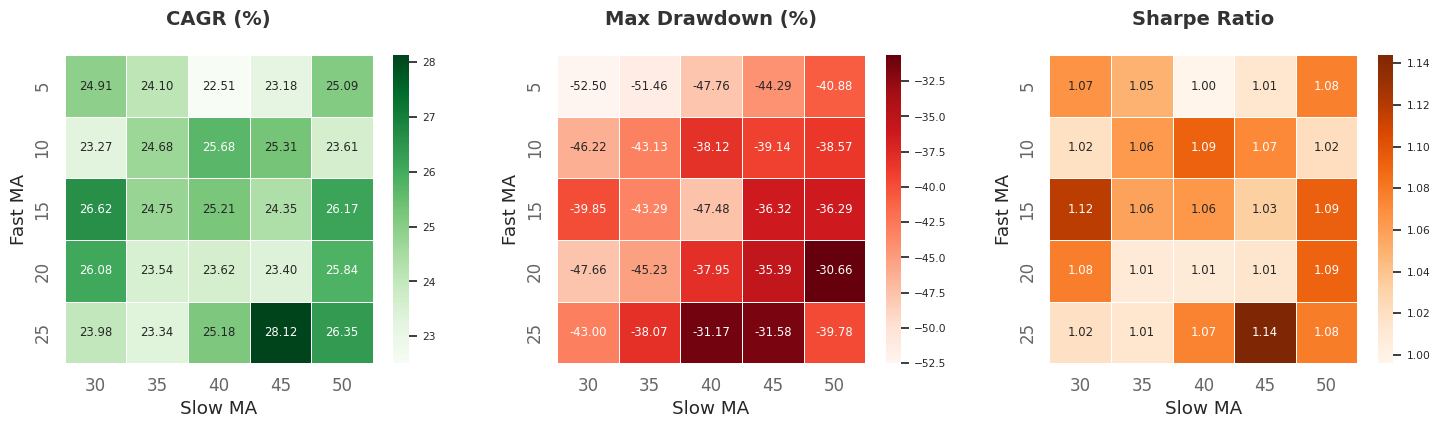

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(18,4))

ax[0].set_title('CAGR (%)\n', fontsize=14, fontweight='bold')
ax[1].set_title('Max Drawdown (%)\n', fontsize=14, fontweight='bold')
ax[2].set_title('Sharpe Ratio\n', fontsize=14, fontweight='bold')

reshape = lambda d: pd.DataFrame(d.values.reshape(len(d.index.levels[0]), len(d.index.levels[1])), d.index.levels[0], d.index.levels[1])

sns.set_theme(font_scale=.7)
sns.heatmap(reshape(optimization_results['CAGR (%)']), ax=ax[0], annot=True, fmt='.2f', linewidth=.5, square=True, cmap='Greens')
sns.heatmap(reshape(optimization_results['Max Drawdown (%)']), ax=ax[1], annot=True, fmt='.2f', linewidth=.5, square=True, cmap='Reds')
sns.heatmap(reshape(optimization_results['Sharpe Ratio']), ax=ax[2], annot=True, fmt='.2f', linewidth=.5, square=True, cmap='Oranges')

plt.show()

In [9]:
best_params = optimization_results_sorted.index[0]
best_params

(np.int64(25), np.int64(45))

In [10]:
result = backtest.run(*best_params)

In [11]:
import quantstats as qs
qs.reports.metrics(result.returns, benchmark)

                    Strategy    Benchmark
------------------  ----------  -----------
Start Period        2006-01-03  2006-01-03
End Period          2026-03-16  2026-03-16
Risk-Free Rate      0.0%        0.0%
Time in Market      100.0%      100.0%

Cumulative Return   14,870.92%  1,347.95%
CAGR﹪              28.12%      14.14%

Sharpe              1.14        0.71
Prob. Sharpe Ratio  100.0%      99.93%
Sortino             1.67        1.01
Sortino/√2          1.18        0.71
Omega               1.22        1.22

Max Drawdown        -31.58%     -53.85%
Longest DD Days     652         1161

Gain/Pain Ratio     0.22        0.14
Gain/Pain (1M)      1.71        0.89

Payoff Ratio        0.93        0.86
Profit Factor       1.22        1.14
Common Sense Ratio  1.16        1.04
CPC Index           0.64        0.54
Tail Ratio          0.95        0.92
Outlier Win Ratio   3.54        4.2
Outlier Loss Ratio  3.67        4.1

MTD                 -2.9%       -1.96%
3M                  2.11%       

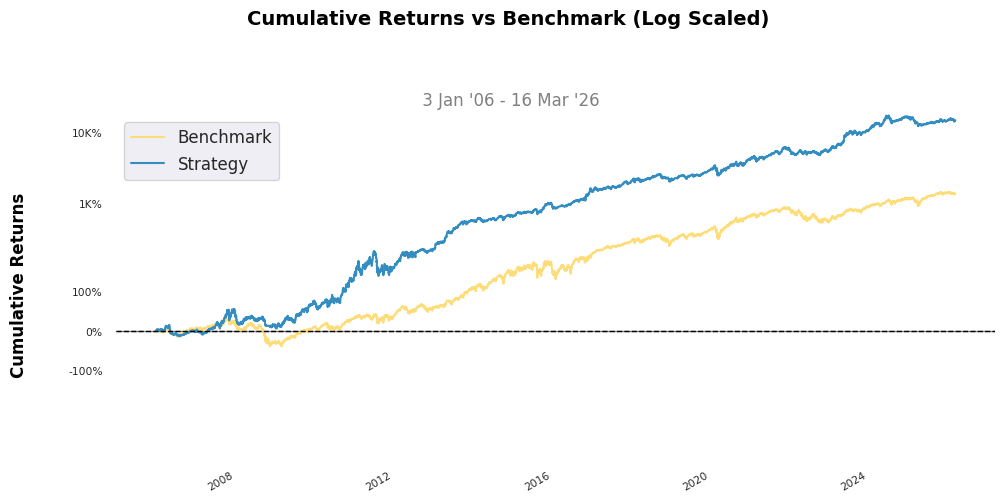

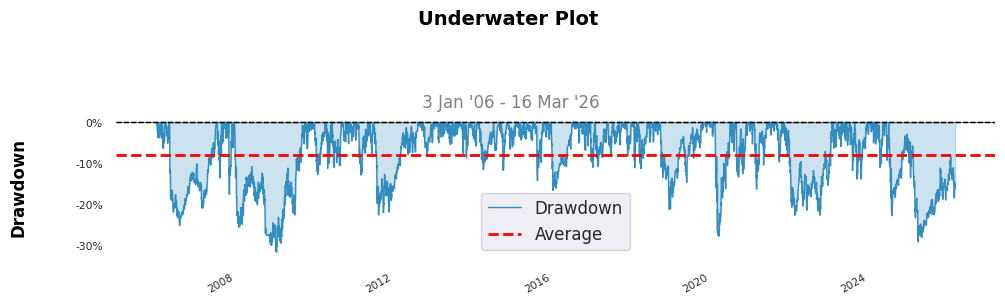

In [12]:
qs.plots.log_returns(result.returns, benchmark, fontname='sans-serif')
qs.plots.drawdown(result.returns, figsize=(10,3), fontname='sans-serif')

In [13]:
import pandas as pd

periodic_returns = result.returns.pct_change()

# Compound periodic returns into monthly returns
monthly_returns = (1 + periodic_returns).resample("ME").prod() - 1
monthly_grid = (
    monthly_returns.to_frame("Monthly Returns")
    .assign(year=lambda df: df.index.year, month=lambda df: df.index.month)
    .pivot(index="year", columns="month", values="Monthly Returns")
    .reindex(columns=range(1, 13))
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_grid.columns = month_labels

# Add yearly compounded return as the last column
yearly_returns = (1 + periodic_returns).resample("YE").prod() - 1
monthly_grid["Year"] = yearly_returns.values

# Human-readable format like 5.35%
monthly_grid_pct = monthly_grid.map(lambda x: f"{x:.2%}" if pd.notna(x) else "-")
monthly_grid_pct

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Year
year,,,,,,,,,,,,,
2006,4.17%,-1.86%,7.01%,0.57%,-13.58%,-0.06%,-4.77%,-0.08%,4.04%,3.87%,3.57%,-1.38%,-0.20%
2007,-0.61%,-4.46%,0.01%,7.46%,5.90%,0.66%,7.85%,5.37%,7.63%,15.09%,-3.54%,4.81%,54.81%
2008,-22.14%,-0.95%,6.56%,5.78%,2.59%,-6.61%,1.53%,0.96%,-2.16%,-11.80%,0.77%,-1.21%,-26.65%
2009,-0.22%,1.09%,7.31%,12.24%,-6.43%,0.03%,9.63%,2.97%,6.17%,-3.79%,11.91%,5.20%,54.34%
2010,-10.37%,3.06%,6.24%,1.19%,1.28%,-1.44%,1.07%,-0.60%,18.48%,4.77%,9.20%,-3.35%,30.48%
2011,12.99%,-0.30%,4.05%,0.72%,7.22%,1.00%,-1.68%,-11.94%,-0.15%,3.76%,-0.45%,-0.37%,13.73%
2012,3.42%,5.22%,6.00%,0.91%,-2.05%,0.02%,1.98%,3.71%,2.11%,-3.42%,1.52%,0.53%,21.40%
2013,14.54%,3.50%,4.24%,10.15%,14.38%,-0.54%,11.89%,8.47%,8.98%,-1.08%,3.40%,2.40%,114.53%
2014,-2.54%,8.52%,-6.67%,-1.09%,4.38%,0.71%,-2.69%,9.00%,2.48%,-1.42%,6.29%,-3.46%,12.85%


In [14]:
trades = pd.DataFrame(result.trades)
trades

,symbol,open_date,close_date,open_price,close_price,position_size,leverage,profit_loss,change_pct,trade_commission,cumulative_return
0,NFLX,2006-01-03,2006-01-05,0.386571,0.355286,51733,1.0,-1618.466280,-8.092948,38.378488,9.983432e+05
1,LIN,2006-01-03,2006-01-05,36.190562,36.395039,553,1.0,113.076020,0.565002,40.139837,9.984161e+05
2,PEP,2006-01-03,2006-01-05,33.408812,33.235973,599,1.0,-103.530838,-0.517347,39.920226,9.982726e+05
3,AMGN,2006-01-03,2006-01-05,53.678225,54.050240,373,1.0,138.761324,0.693045,40.182717,9.983712e+05
4,KLAC,2006-01-03,2006-01-05,26.123197,26.631583,765,1.0,388.915254,1.946109,40.357407,9.987198e+05
...,...,...,...,...,...,...,...,...,...,...,...
3301,NVDA,2026-02-11,2026-03-06,192.439583,179.830259,16063,1.0,-202543.571145,-6.552355,5979.770461,1.375784e+08
3302,NVDA,2026-02-23,2026-03-06,191.389641,179.830259,16324,1.0,-188695.361978,-6.039712,6059.793647,1.373837e+08
3303,NVDA,2026-03-05,2026-03-06,181.160197,179.830259,16783,1.0,-22320.360870,-0.734123,6058.502823,1.373553e+08
3304,AAPL,2026-03-05,2026-03-09,260.790009,255.690002,11658,1.0,-59455.871155,-1.955599,6021.123968,1.372898e+08


In [15]:
remaining_positions = pd.DataFrame(result.open_positions)
remaining_positions

,symbol,open_date,last_date,open_price,last_price,position_size,leverage,profit_loss,change_pct,current_value
0,WMT,2025-05-02,2026-03-13,97.287742,126.519997,27077,1.0,7.915218e+05,30.047212,3.425782e+06
1,WMT,2025-05-07,2026-03-13,97.883691,126.519997,26252,1.0,7.517603e+05,29.255441,3.321403e+06
2,WMT,2025-05-12,2026-03-13,97.244181,126.519997,26317,1.0,7.704516e+05,30.105468,3.329627e+06
3,WMT,2025-11-19,2026-03-13,101.373355,126.519997,28716,1.0,7.221110e+05,24.805968,3.633148e+06
4,ASML,2025-11-19,2026-03-13,1004.445207,1345.689941,2898,1.0,9.889272e+05,33.973454,3.899809e+06
5,MU,2025-11-19,2026-03-13,226.818372,426.130005,12834,1.0,2.557966e+06,87.872791,5.468952e+06
6,WMT,2025-12-05,2026-03-13,114.496607,126.519997,26381,1.0,3.171890e+05,10.501088,3.337724e+06
7,ASML,2025-12-05,2026-03-13,1120.452227,1345.689941,2696,1.0,6.072409e+05,20.102393,3.627980e+06
8,MU,2025-12-05,2026-03-13,228.857542,426.130005,13198,1.0,2.603602e+06,86.198804,5.624064e+06
9,CSCO,2025-12-05,2026-03-13,77.555000,78.330002,38944,1.0,3.018166e+04,0.999293,3.050484e+06
